<a href="https://colab.research.google.com/github/riasad30/Programming_In_Python_Final/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Python Final Project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
url = "https://raw.githubusercontent.com/riasad30/Programming_In_Python_Final/main/anime.csv"
df = pd.read_csv(url)
df.head()

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...
4,9969,Gintama',9.02,11,406,601940,"After a one-year hiatus, Shinpachi Shimura ret...",2011-01-01,2012-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/4/503...


In [5]:
print("Dataset shape (rows, columns):", df.shape)

Dataset shape (rows, columns): (10000, 12)


In [6]:
print("Dataset columns:", df.columns.tolist())

Dataset columns: ['anime_id', 'title', 'score', 'rank', 'popularity', 'members', 'synopsis', 'start_date', 'end_date', 'type', 'episodes', 'image_url']


In [7]:
print("Data types  :\n", df.dtypes)

Data types  :
 anime_id        int64
title          object
score         float64
rank            int64
popularity      int64
members         int64
synopsis       object
start_date     object
end_date       object
type           object
episodes      float64
image_url      object
dtype: object


In [8]:
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anime_id    10000 non-null  int64  
 1   title       10000 non-null  object 
 2   score       10000 non-null  float64
 3   rank        10000 non-null  int64  
 4   popularity  10000 non-null  int64  
 5   members     10000 non-null  int64  
 6   synopsis    9998 non-null   object 
 7   start_date  9998 non-null   object 
 8   end_date    9916 non-null   object 
 9   type        10000 non-null  object 
 10  episodes    9952 non-null   float64
 11  image_url   10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


In [9]:
print("Summary statistics:")
print(df.describe())

Summary statistics:
           anime_id         score          rank    popularity       members  \
count  10000.000000  10000.000000  10000.000000  10000.000000  1.000000e+04   
mean   24129.128000      6.980589   5000.494000   6490.903700  1.075309e+05   
std    19948.188153      0.619406   2886.898727   4646.309341  2.733514e+05   
min        1.000000      6.050000      1.000000      1.000000  2.260000e+02   
25%     4055.500000      6.470000   2500.750000   2591.750000  4.270250e+03   
50%    21406.000000      6.900000   5000.500000   5564.500000  1.817900e+04   
75%    40028.750000      7.390000   7500.250000   9824.250000  8.469275e+04   
max    62863.000000      9.290000  10000.000000  22184.000000  4.262220e+06   

          episodes  
count  9952.000000  
mean     15.702271  
std      41.865696  
min       1.000000  
25%       1.000000  
50%      11.000000  
75%      13.000000  
max    1787.000000  


In [10]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
anime_id       0
title          0
score          0
rank           0
popularity     0
members        0
synopsis       2
start_date     2
end_date      84
type           0
episodes      48
image_url      0
dtype: int64


In [11]:
df = df.dropna(subset=['synopsis', 'start_date'])

df['episodes'] = df['episodes'].fillna(df['episodes'].median())

df['end_date'] = df['end_date'].fillna("Unknown")


print("Missing values after:")
print(df.isnull().sum())

Missing values after:
anime_id      0
title         0
score         0
rank          0
popularity    0
members       0
synopsis      0
start_date    0
end_date      0
type          0
episodes      0
image_url     0
dtype: int64


In [12]:
print("Duplicate rows before:", df.duplicated().sum())

Duplicate rows before: 1


In [13]:
df = df.drop_duplicates()
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows after: 0


In [14]:
print("Data types before:")
print(df.dtypes)

Data types before:
anime_id        int64
title          object
score         float64
rank            int64
popularity      int64
members         int64
synopsis       object
start_date     object
end_date       object
type           object
episodes      float64
image_url      object
dtype: object


In [15]:
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')


print("Data types after:")
print(df.dtypes)

Data types after:
anime_id               int64
title                 object
score                float64
rank                   int64
popularity             int64
members                int64
synopsis              object
start_date    datetime64[ns]
end_date      datetime64[ns]
type                  object
episodes             float64
image_url             object
dtype: object


Extract year from start_date
Create popularity group (based on members)
Normalize score (0 to 1 scale)

In [16]:


df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['year'] = df['start_date'].dt.year


df['popularity_group'] = pd.cut(
    df['members'],
    bins=[0, 10000, 100000, df['members'].max()],
    labels=['Low', 'Medium', 'High']
)


df['score_normalized'] = (
    (df['score'] - df['score'].min()) /
    (df['score'].max() - df['score'].min())
)


print(df[['year', 'popularity_group', 'score_normalized']].head())

   year popularity_group  score_normalized
0  2015             High          0.925926
1  2025             High          0.966049
2  2011             High          0.919753
3  2023             High          1.000000
4  2011             High          0.916667


Average score by type

In [17]:

group_type = df.groupby('type')['score'].mean()
print("Average score by type  :\n", group_type)

Average score by type  :
 type
Movie         7.067724
ONA           6.876420
OVA           6.880923
Special       6.788544
TV            7.069319
TV Special    6.788545
Name: score, dtype: float64


Comparison 1: Type vs Score

In [18]:
print("Average score by type:")
print(df.groupby('type')['score'].mean())

Average score by type:
type
Movie         7.067724
ONA           6.876420
OVA           6.880923
Special       6.788544
TV            7.069319
TV Special    6.788545
Name: score, dtype: float64


Comparison 2: Popularity Group vs Members

In [19]:
print(df.groupby(df['popularity_group'].astype(str))['members'].mean())

popularity_group
High      406184.300000
Low         3785.917209
Medium     38048.073321
Name: members, dtype: float64


Relationship Analysis- Score , Members

Correlation:
             score   members
score    1.000000  0.436446
members  0.436446  1.000000


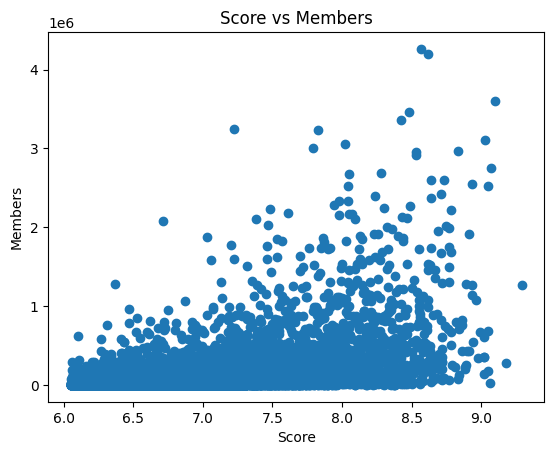

In [20]:
corr = df[['score', 'members']].corr()
print("Correlation:\n", corr)


plt.scatter(df['score'], df['members'])
plt.xlabel("Score")
plt.ylabel("Members")
plt.title("Score vs Members")
plt.show()

Detect outliers using IQR

In [21]:

Q1 = df['score'].quantile(0.25)
Q3 = df['score'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['score'] < Q1 - 1.5*IQR) | (df['score'] > Q3 + 1.5*IQR)]

print("Outliers in score:")
print(outliers[['title', 'score']])

Outliers in score:
                                                title  score
0                                            Gintama°   9.05
1                        Chainsaw Man Movie: Reze-hen   9.18
2                              Hunter x Hunter (2011)   9.03
3                                   Sousou no Frieren   9.29
4                                            Gintama'   9.02
5                                 Gintama': Enchousen   9.02
6                                  Gintama: The Final   9.05
7                  Shingeki no Kyojin Season 3 Part 2   9.05
8                                            Gintama.   8.98
9                           Bleach: Sennen Kessen-hen   8.99
10                   Fullmetal Alchemist: Brotherhood   9.10
11         Kaguya-sama wa Kokurasetai: Ultra Romantic   8.96
12                                            Gintama   8.93
13                               Clannad: After Story   8.93
14                  Kusuriya no Hitorigoto 2nd Season   8.91
15   

Date is converted

Number of anime per year

Anime released per year:
 year
1956      1
1959      1
1960      1
1961      3
1962      1
       ... 
2021    418
2022    416
2023    473
2024    442
2025    329
Length: 68, dtype: int64


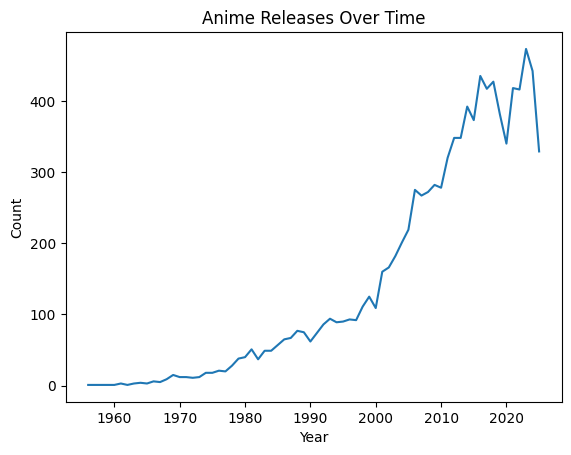

In [22]:

df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['year'] = df['start_date'].dt.year


trend = df.groupby('year').size()

print("Anime released per year:\n", trend)


trend.plot(kind='line')
plt.title("Anime Releases Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

Mean - This is the average rating of all anime

Percentile - 90% of anime have a score less than 7.84

Z-score - how far a value is from the average

In [23]:

print("Mean score:", np.mean(df['score']))


print("90th percentile of score:", np.percentile(df['score'], 90))


df['z_score'] = (df['score'] - np.mean(df['score'])) / np.std(df['score'])
print("Z-score sample:\n", df[['score', 'z_score']].head())


df['score_norm'] = (df['score'] - np.min(df['score'])) / (np.max(df['score']) - np.min(df['score']))

Mean score: 6.980828414207104
90th percentile of score: 7.84
Z-score sample:
    score   z_score
0   9.05  3.340724
1   9.18  3.550612
2   9.03  3.308433
3   9.29  3.728209
4   9.02  3.292288


Bar Chart (Average Score by Type)

Compares average ratings across anime types


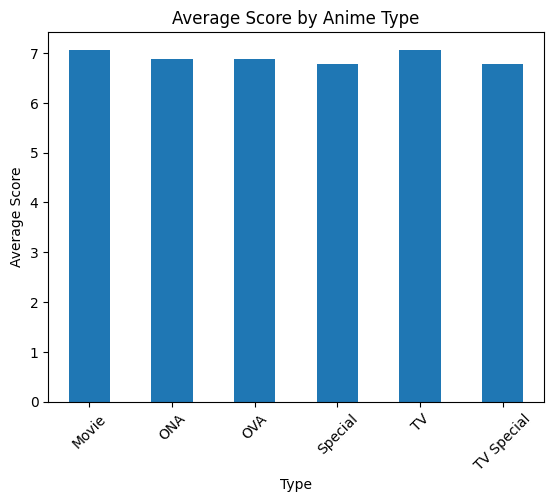

In [24]:


avg_score = df.groupby('type')['score'].mean()

avg_score.plot(kind='bar')
plt.title("Average Score by Anime Type")
plt.xlabel("Type")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

Line Chart (Trend Over Time)

Number of anime released each year.

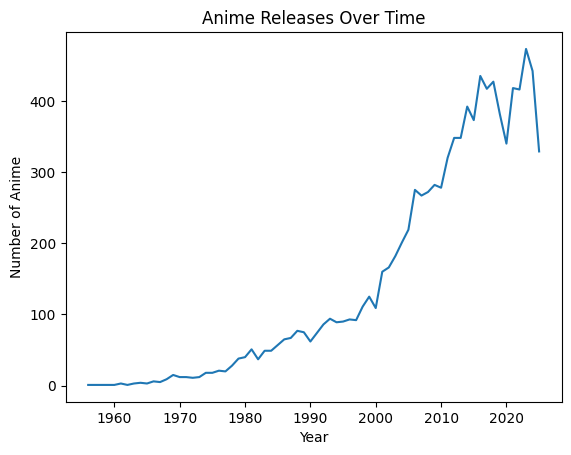

In [25]:
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['year'] = df['start_date'].dt.year

trend = df.groupby('year').size()

trend.plot(kind='line')
plt.title("Anime Releases Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Anime")
plt.show()

Histogram-Distribution of ratings.


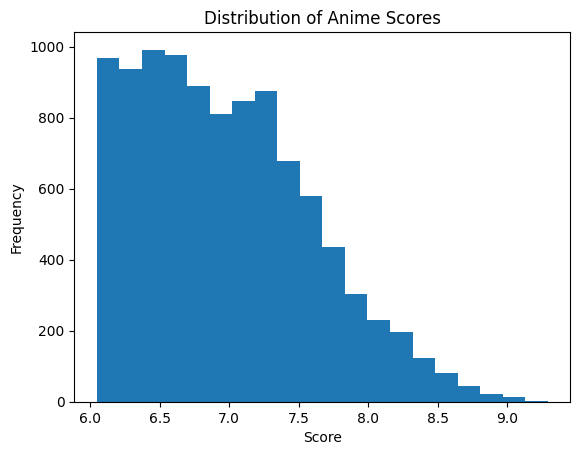

In [26]:
df['score'].plot(kind='hist', bins=20)
plt.title("Distribution of Anime Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

Scatter Plot - Relationship between rating and popularity.

Box Plot- It shows the spread and outliers in scores.

It helps detect unusual values.

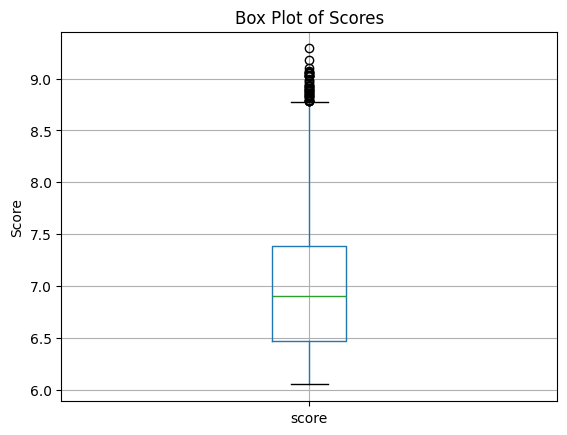

In [28]:
df.boxplot(column='score')
plt.title("Box Plot of Scores")
plt.ylabel("Score")
plt.show()

1.Most anime have moderate ratings

The average score of the dataset is approximately 6.98, and the histogram shows that most values are concentrated between 6 and 8. This indicates that the majority of anime are neither poorly rated nor exceptionally high-rated. Instead, most fall into a moderate quality range, suggesting a stable industry where extreme ratings are less common.

2.High-quality anime are relatively rare

The 90th percentile score is 7.84, meaning only the top 10% of anime exceed this value. This shows that exceptional anime are limited, and achieving a very high rating is difficult. It also indicates strong competition in the industry, where only a small portion of content reaches top-tier quality.

3.Positive relationship between rating and popularity

The scatter plot and correlation analysis indicate a positive relationship between score and number of members. This means that anime with higher ratings tend to attract more viewers. This relationship suggests that quality influences popularity, as audiences are more likely to watch and recommend highly rated anime.

4.Growth in anime production over time

Trend analysis based on the release year shows that the number of anime has generally increased over time. This suggests that the anime industry is expanding, with more content being produced each year. The growth may be driven by increasing global demand and digital streaming platforms.

5.Popularity is highly uneven across groups

The subgroup analysis shows that anime in the High popularity group have extremely large member counts compared to Medium and Low groups. This indicates that audience engagement is not evenly distributed — a small number of anime dominate the majority of viewers, while many others remain less popular.